# 1. Setup & Config

## 1.1 Imports

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 200)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 110

sns.set_theme(style="whitegrid")

## 1.2 Global Config

Paths, random seed, display settings

In [3]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [4]:
# Competition / project config
COMPETITION_NAME = "playground-series-s6e3"
TARGET_COL = "Churn"
ID_COL = "id"

# Kaggle path
KAGGLE_BASE = f"/kaggle/input/competitions/{COMPETITION_NAME}/"

# Local project paths
PROJECT_ROOT = Path("..")
LOCAL_DATA_DIR = PROJECT_ROOT / "data" / "raw"
LOCAL_OUTPUT_DIR = PROJECT_ROOT / "outputs"
LOCAL_FIGURE_DIR = LOCAL_OUTPUT_DIR / "figures"
LOCAL_SUBMISSION_DIR = LOCAL_OUTPUT_DIR / "submissions"

# Environment detection
if os.path.exists(os.path.join(KAGGLE_BASE, "train.csv")):
    BASE_PATH = Path(KAGGLE_BASE)
    ENVIRONMENT = "Kaggle"
else:
    BASE_PATH = LOCAL_DATA_DIR
    ENVIRONMENT = "Local"

print(f"Environment : {ENVIRONMENT}")
print(f"Base path   : {BASE_PATH}")

Environment : Local
Base path   : ..\data\raw


In [5]:
TRAIN_PATH = BASE_PATH / "train.csv"
TEST_PATH = BASE_PATH / "test.csv"
SUB_PATH = BASE_PATH / "sample_submission.csv"

print("Train path       :", TRAIN_PATH)
print("Test path        :", TEST_PATH)
print("Submission path  :", SUB_PATH)

Train path       : ..\data\raw\train.csv
Test path        : ..\data\raw\test.csv
Submission path  : ..\data\raw\sample_submission.csv


In [6]:
if ENVIRONMENT == "Local":
    LOCAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    LOCAL_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    LOCAL_SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

    print("Output folders checked/created:")
    print(" -", LOCAL_OUTPUT_DIR)
    print(" -", LOCAL_FIGURE_DIR)
    print(" -", LOCAL_SUBMISSION_DIR)

Output folders checked/created:
 - ..\outputs
 - ..\outputs\figures
 - ..\outputs\submissions


In [7]:
print("=" * 50)
print("EDA Notebook Config")
print("=" * 50)
print(f"Competition   : {COMPETITION_NAME}")
print(f"Target column : {TARGET_COL}")
print(f"ID column     : {ID_COL}")
print(f"Random state  : {RANDOM_STATE}")
print(f"Environment   : {ENVIRONMENT}")
print("=" * 50)

EDA Notebook Config
Competition   : playground-series-s6e3
Target column : Churn
ID column     : id
Random state  : 42
Environment   : Local


# 2. Data Loading

## 2.1 Load Train / Test / Sample Submission

In [8]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUB_PATH)

print("Files loaded successfully.")

Files loaded successfully.


In [9]:
print(f"Train shape             : {train.shape}")
print(f"Test shape              : {test.shape}")
print(f"Sample submission shape : {sample_submission.shape}")

Train shape             : (594194, 21)
Test shape              : (254655, 20)
Sample submission shape : (254655, 2)


## 2.2 Shape & Basic Info

In [10]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [11]:
test.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [12]:
sample_submission.head()

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0


In [13]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nSample submission columns:")
print(sample_submission.columns.tolist())

Train columns:
['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Test columns:
['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Sample submission columns:
['id', 'Churn']


#### Target & ID Presence Check

In [14]:
print(f"'{ID_COL}' in train  :", ID_COL in train.columns)
print(f"'{ID_COL}' in test   :", ID_COL in test.columns)
print(f"'{TARGET_COL}' in train :", TARGET_COL in train.columns)
print(f"'{TARGET_COL}' in test  :", TARGET_COL in test.columns)

'id' in train  : True
'id' in test   : True
'Churn' in train : True
'Churn' in test  : False


#### Missing Columns Comparison

In [15]:
train_only_cols = set(train.columns) - set(test.columns)
test_only_cols = set(test.columns) - set(train.columns)

print("Columns only in train:", train_only_cols)
print("Columns only in test :", test_only_cols)

Columns only in train: {'Churn'}
Columns only in test : set()


✔ Feature mismatch yok

Bu çok önemli çünkü bazı Kaggle yarışmalarında testte ekstra kolon olur.

In [16]:
summary_df = pd.DataFrame({
    "dataset": ["train", "test", "sample_submission"],
    "rows": [train.shape[0], test.shape[0], sample_submission.shape[0]],
    "columns": [train.shape[1], test.shape[1], sample_submission.shape[1]]
})

summary_df

,dataset,rows,columns
0,train,594194,21
1,test,254655,20
2,sample_submission,254655,2


✔ tree models çok iyi çalışır
✔ overfitting riski düşüktür
✔ feature engineering etkili olur

#### Convert Target to Numeric Copy for Later Analysis

In [17]:
train_eda = train.copy()

if train_eda[TARGET_COL].dtype == "object":
    train_eda[TARGET_COL + "_binary"] = train_eda[TARGET_COL].map({"No": 0, "Yes": 1})
else:
    train_eda[TARGET_COL + "_binary"] = train_eda[TARGET_COL]

train_eda[[TARGET_COL, TARGET_COL + "_binary"]].head()

,Churn,Churn_binary
0,No,0
1,No,0
2,No,0
3,Yes,1
4,Yes,1


# 3. Exploratory Data Analysis

## 3.1 Data Information

- dtypes
- non-null counts
- memory usage

In [18]:
print("Train Dataset Info")
print("=" * 50)

train.info()

Train Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  P

In [19]:
memory_usage = train.memory_usage(deep=True).sort_values(ascending=False)

memory_df = pd.DataFrame({
    "column": memory_usage.index,
    "memory_MB": memory_usage.values / (1024 ** 2)
})

memory_df

,column,memory_MB
0,PaymentMethod,38.295514
1,Contract,34.010473
2,StreamingMovies,31.411827
3,StreamingTV,31.410746
4,InternetService,31.410645
5,DeviceProtection,31.378119
6,OnlineBackup,31.375539
7,TechSupport,31.338834
8,OnlineSecurity,31.337973
9,gender,30.603178


In [20]:
dtype_summary = train.dtypes.value_counts()

dtype_summary

object     16
int64       3
float64     2
Name: count, dtype: int64

## 3.2 Target Balance

- value_counts
- bar plot
- pie chart

In [21]:
target_counts = train[TARGET_COL].value_counts()

target_counts

Churn
No     460377
Yes    133817
Name: count, dtype: int64

In [22]:
target_percentage = train[TARGET_COL].value_counts(normalize=True) * 100

target_percentage

Churn
No     77.479241
Yes    22.520759
Name: proportion, dtype: float64

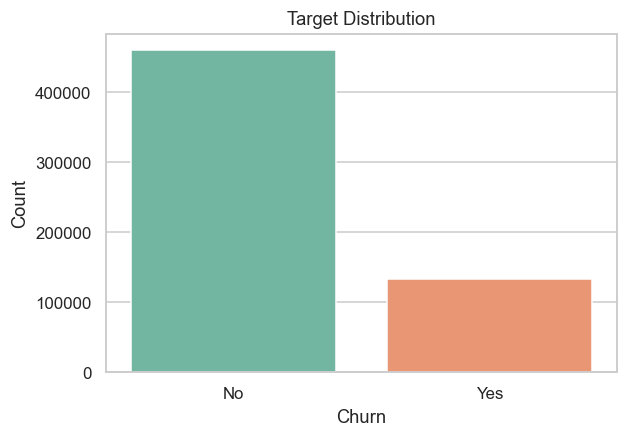

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x=TARGET_COL,
    palette="Set2"
)

plt.title("Target Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

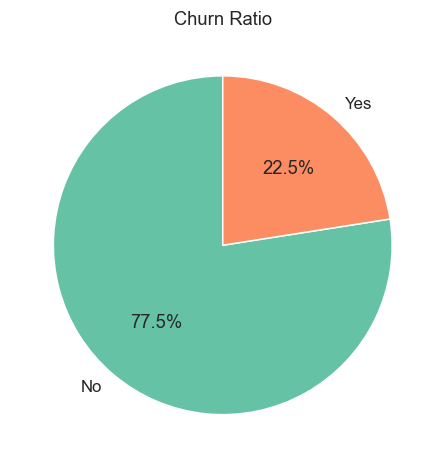

In [24]:
train[TARGET_COL].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(5,5),
    startangle=90,
    colors=sns.color_palette("Set2")
)

plt.title("Churn Ratio")
plt.ylabel("")

plt.show()

## 3.3 Numerical & Categorical Feature Inventory

- Hangi kolonlar numerical
- Hangi kolonlar categorical

#### Feature Type Detection

In [25]:
feature_cols = [c for c in train.columns if c not in [TARGET_COL, ID_COL]]

numerical_cols = train[feature_cols].select_dtypes(
    include=["int64","float64","int32","float32"]
).columns.tolist()

categorical_cols = train[feature_cols].select_dtypes(
    include=["object","category","bool"]
).columns.tolist()

binary_like_cols = [
    col for col in numerical_cols
    if train[col].nunique() <= 2
]

pure_numerical_cols = [
    col for col in numerical_cols
    if col not in binary_like_cols
]

#### Feature Lists

In [26]:
print("Total features:", len(feature_cols))

print("\nNumerical features:")
print(numerical_cols)

print("\nPure numerical features:")
print(pure_numerical_cols)

print("\nCategorical features:")
print(categorical_cols)

print("\nBinary-like features:")
print(binary_like_cols)

Total features: 19

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Pure numerical features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Binary-like features:
['SeniorCitizen']


## 3.4 Missing Value Analysis

- Her kolon için missing count & %
- Heatmap

In [27]:
missing_count = train.isnull().sum()

missing_percentage = (train.isnull().sum() / len(train)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
}).sort_values("missing_percentage", ascending=False)

missing_df

,missing_count,missing_percentage
id,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


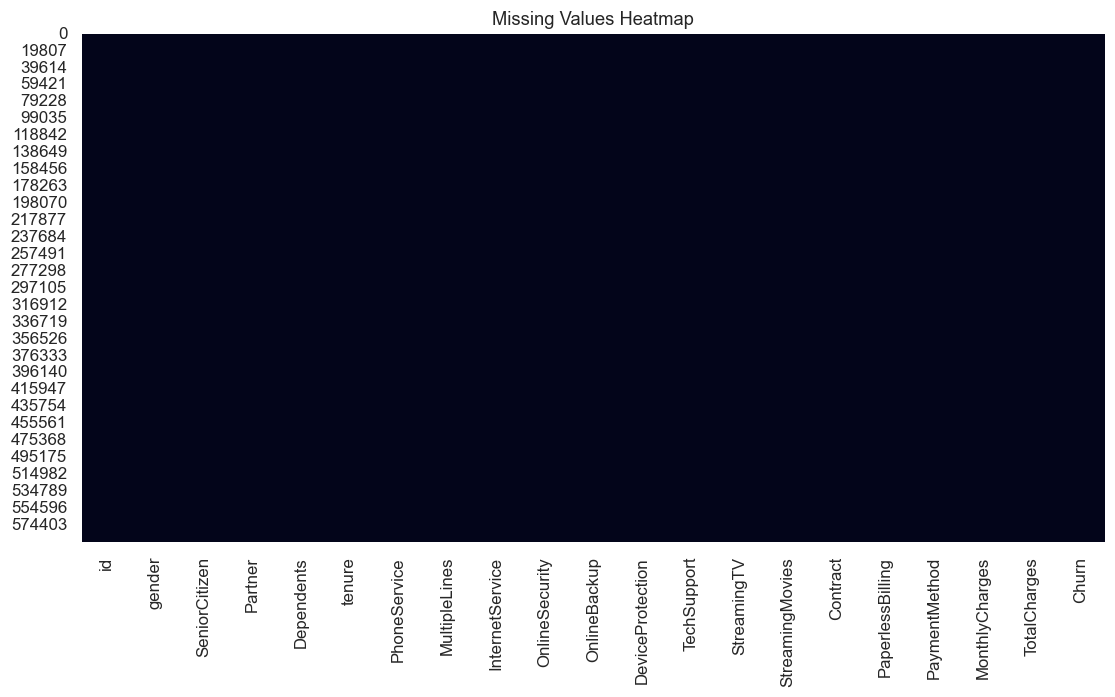

In [28]:
plt.figure(figsize=(12,6))

sns.heatmap(
    train.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")

plt.show()

## 3.5 Duplicate Row Check

In [30]:
duplicate_rows = train.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [31]:
duplicate_percentage = duplicate_rows / len(train) * 100

print(f"Duplicate percentage: {duplicate_percentage:.4f}%")

Duplicate percentage: 0.0000%


## 3.6 Numerical Feature Distributions

- Histogram + KDE her numerical kolon için

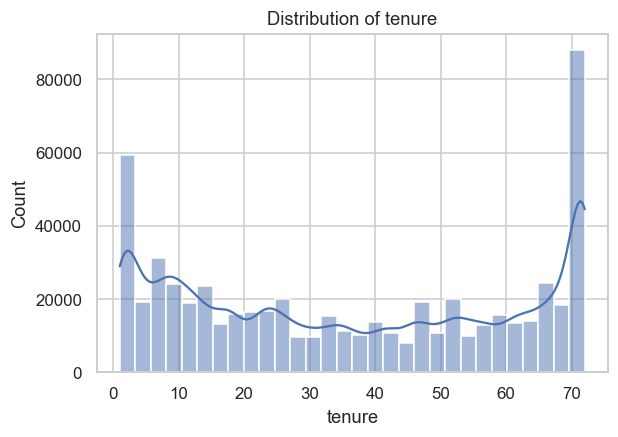

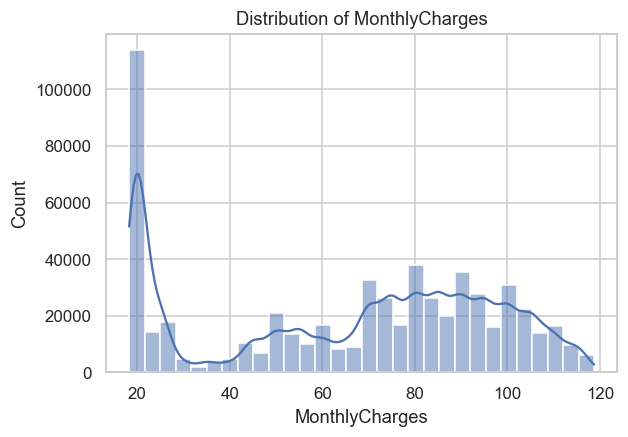

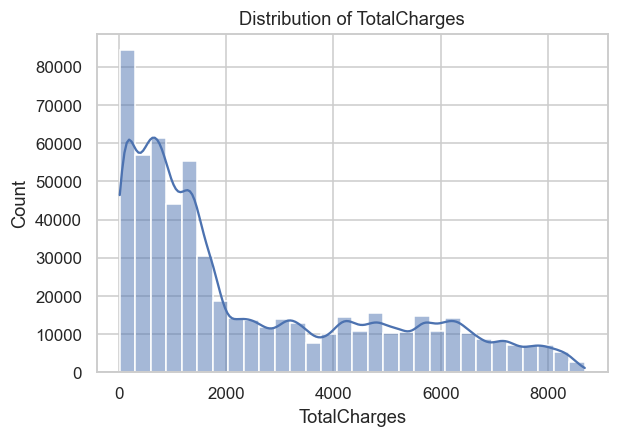

In [32]:
for col in pure_numerical_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        train[col],
        kde=True,
        bins=30
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.show()

## 3.7 Categorical Feature Distributions

- Bar chart her categorical kolon için

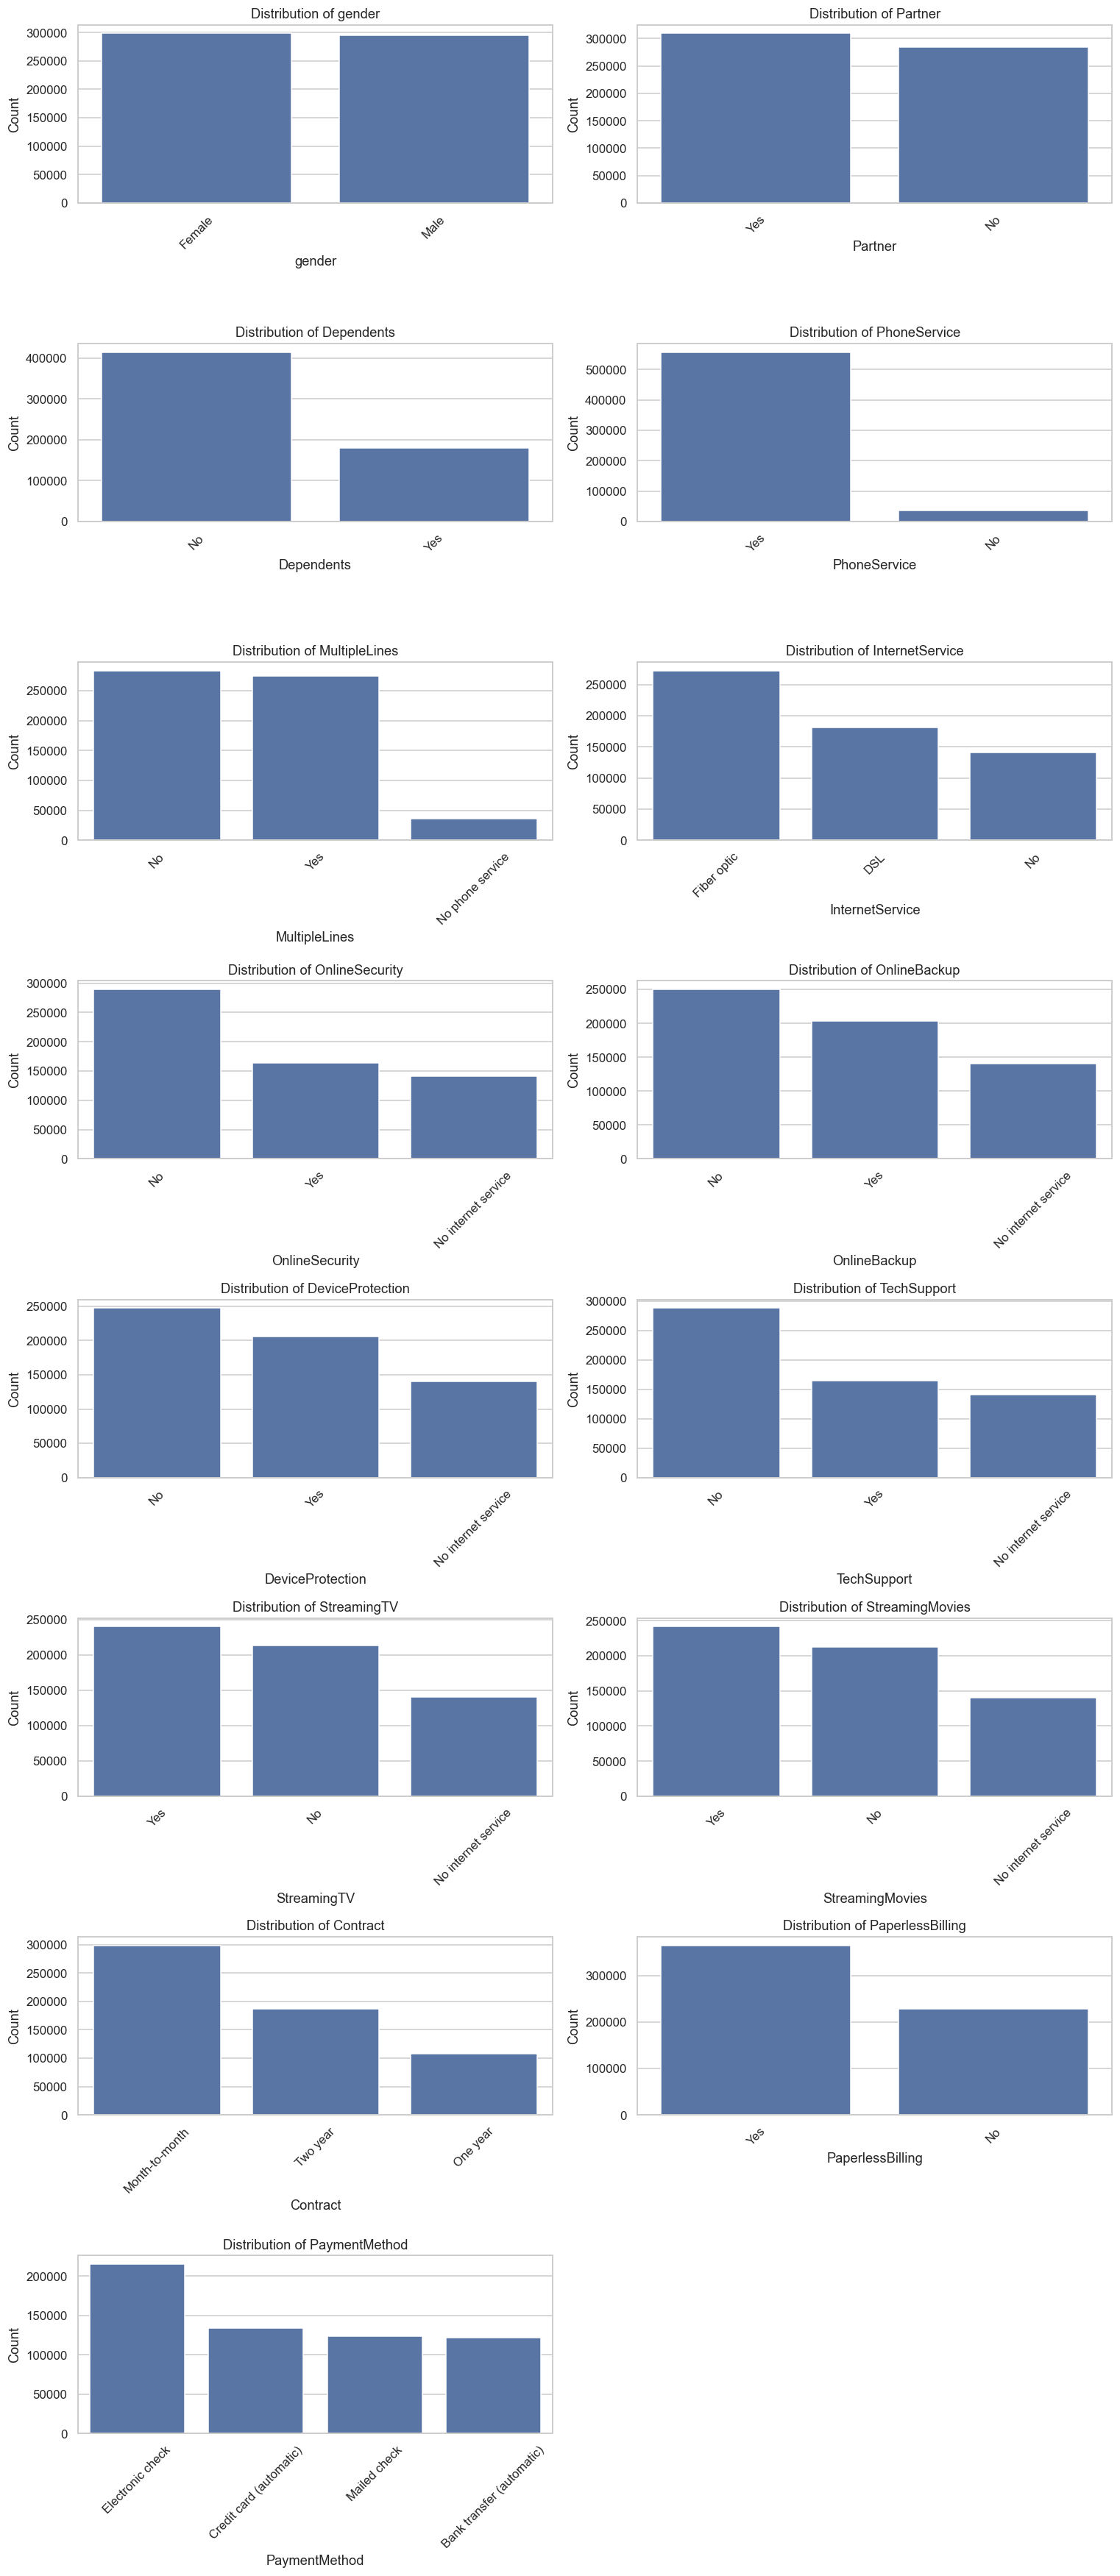

In [41]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    value_counts = train[col].value_counts()
    
    sns.barplot(
        x=value_counts.index,
        y=value_counts.values,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

# kullanılmayan eksenleri kapat
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 3.8 Numerical Distribution by Target

- Boxplot / violin plot (target'a göre ayrılmış)

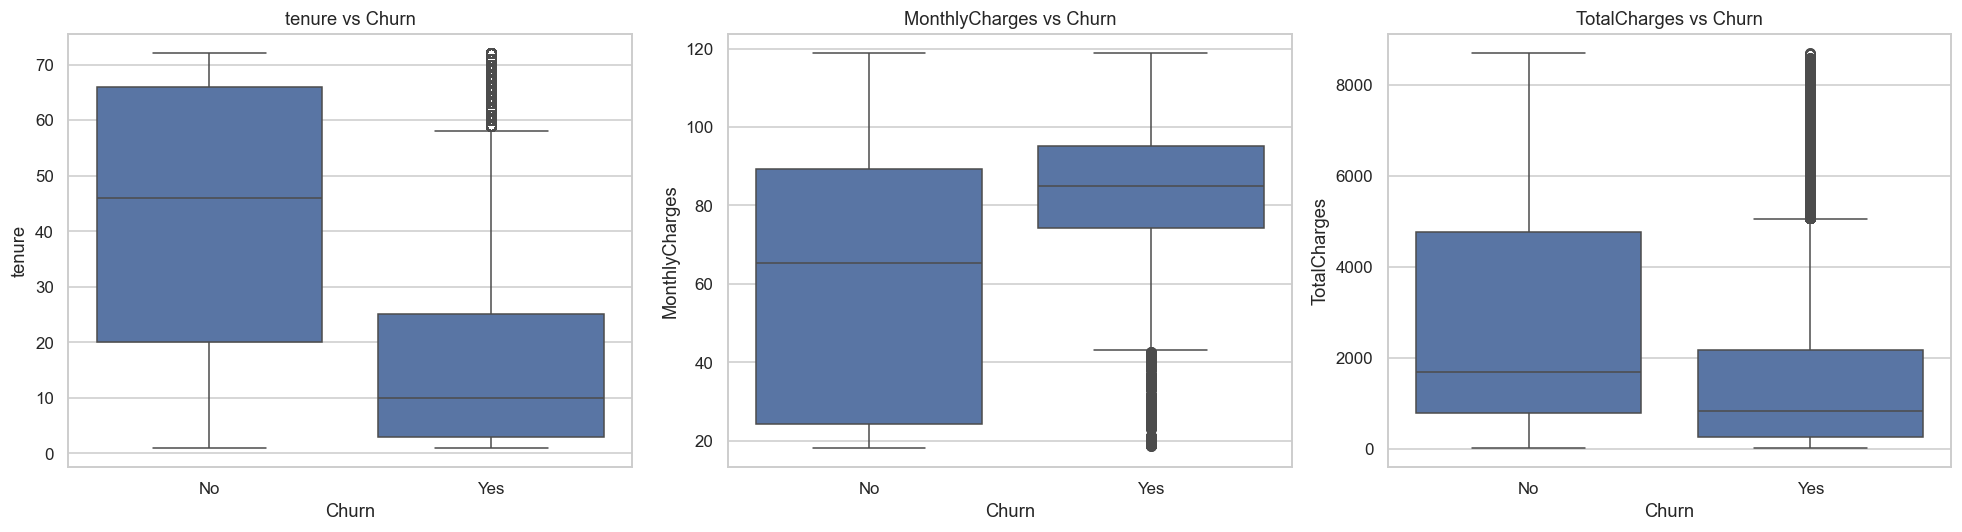

In [45]:
fig, axes = plt.subplots(1, len(pure_numerical_cols), figsize=(18, 5))

for i, col in enumerate(pure_numerical_cols):
    sns.boxplot(
        data=train,
        x=TARGET_COL,
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs {TARGET_COL}")

plt.tight_layout()
plt.show()

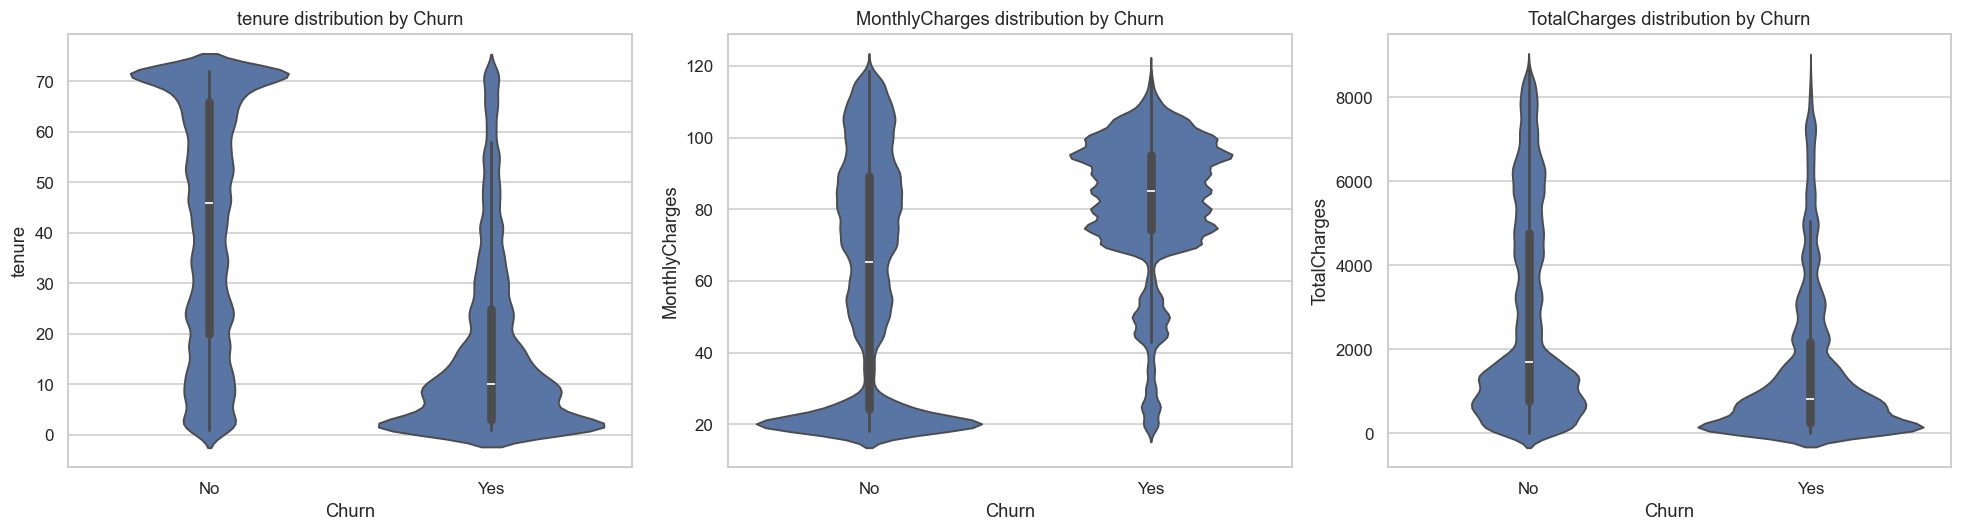

In [46]:
fig, axes = plt.subplots(1, len(pure_numerical_cols), figsize=(18, 5))

for i, col in enumerate(pure_numerical_cols):
    sns.violinplot(
        data=train,
        x=TARGET_COL,
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} distribution by {TARGET_COL}")

plt.tight_layout()
plt.show()

## 3.9 Categorical Feature vs Target

- Stacked bar / grouped bar

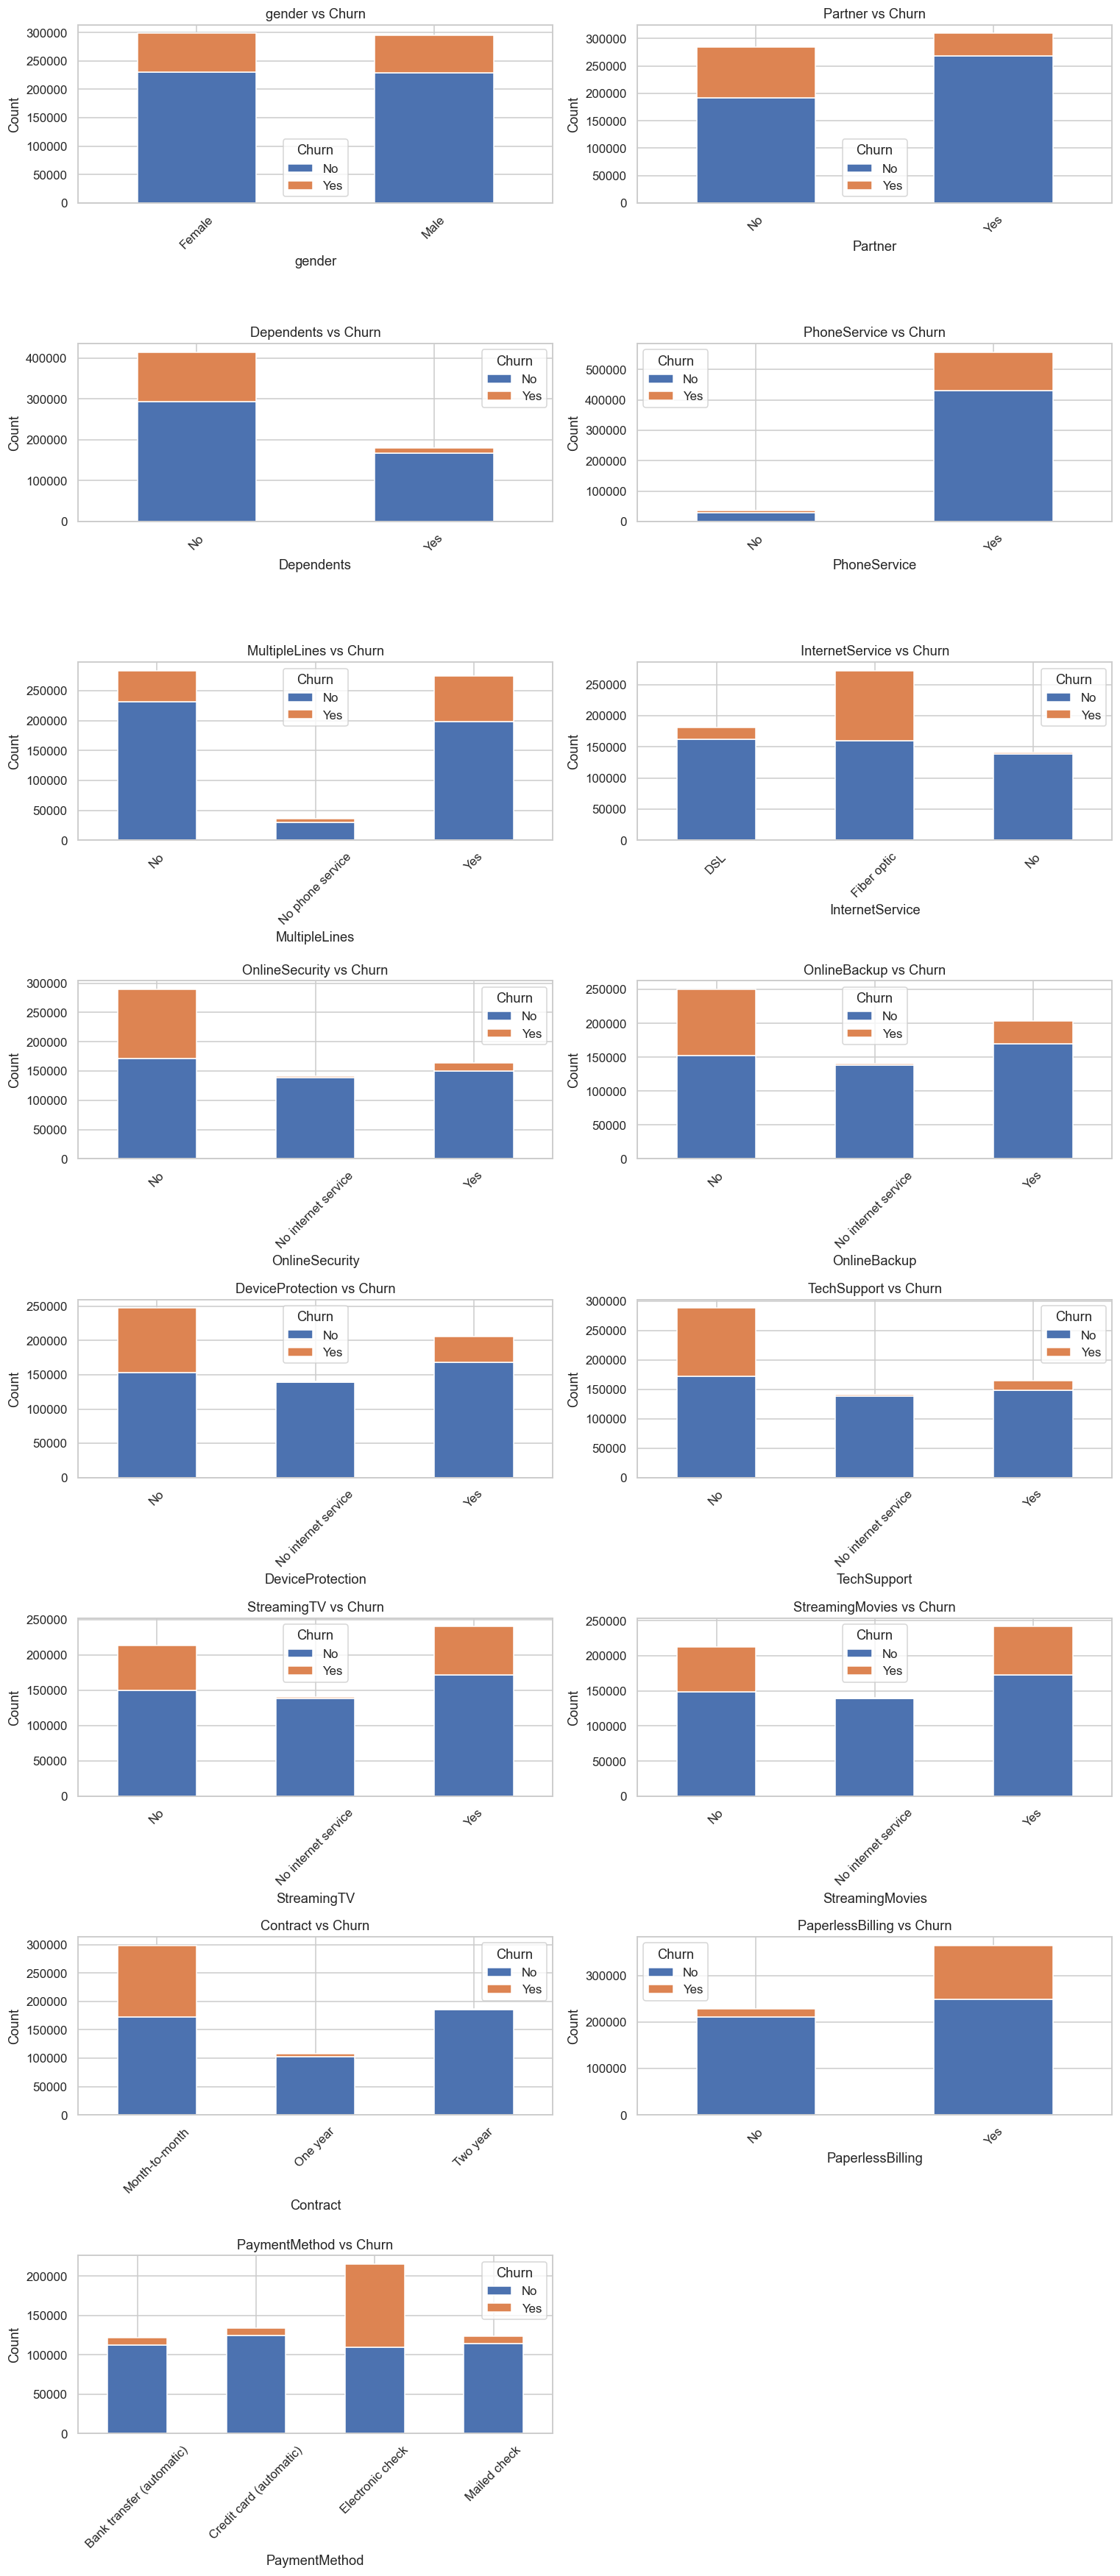

In [42]:
import math
import matplotlib.pyplot as plt

n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    cross_tab = pd.crosstab(train[col], train[TARGET_COL])
    
    cross_tab.plot(
        kind="bar",
        stacked=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} vs {TARGET_COL}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

# kullanılmayan eksenleri kapat
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

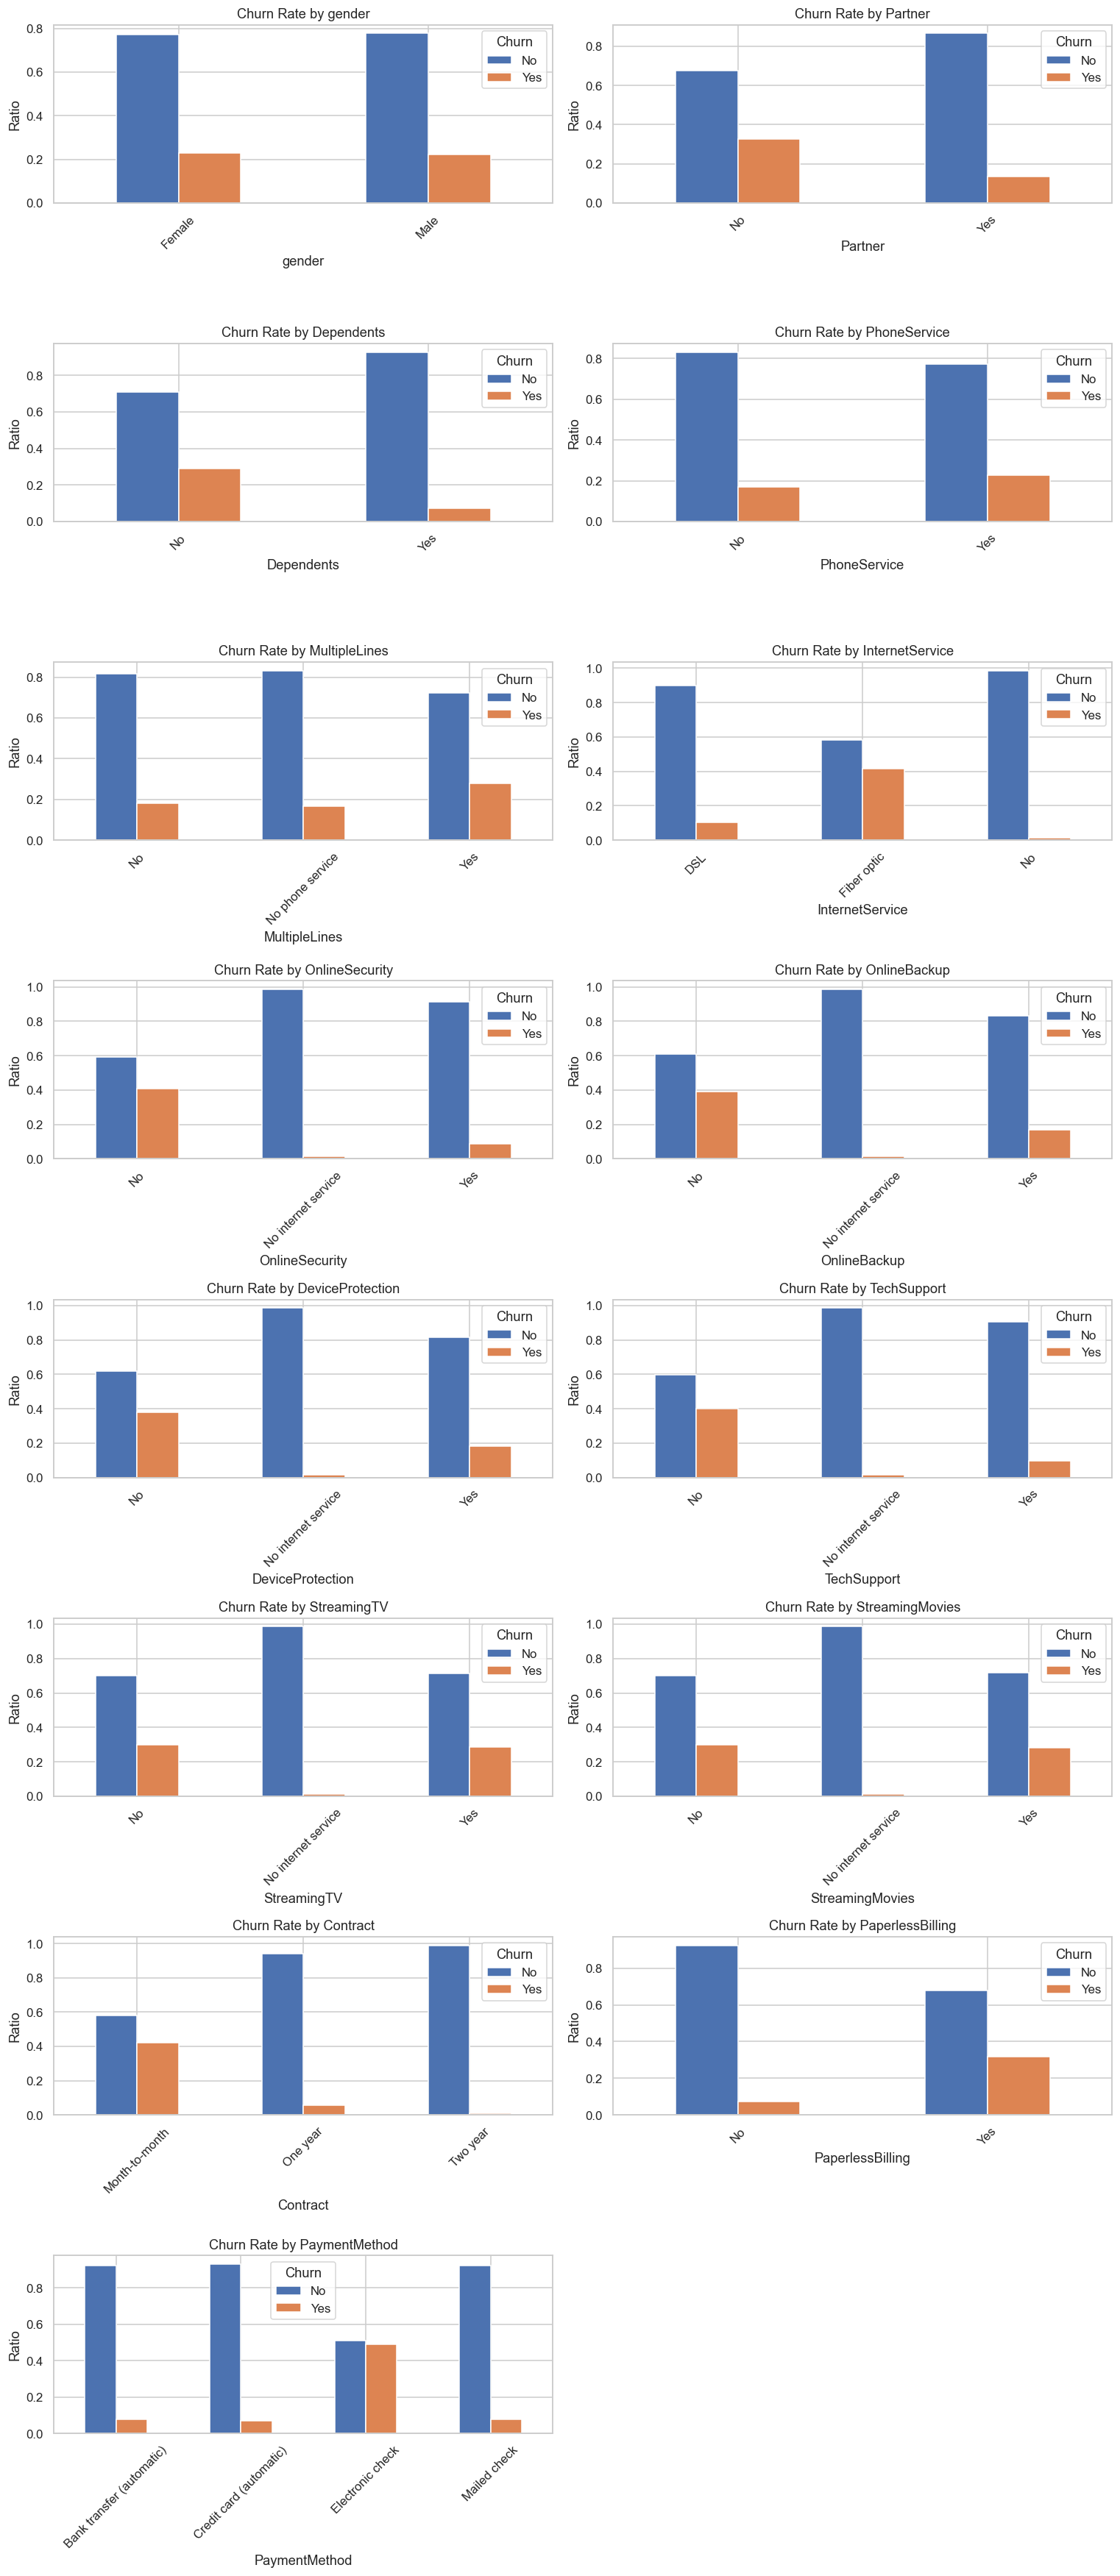

In [43]:
import math
import matplotlib.pyplot as plt

n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = pd.crosstab(
        train[col],
        train[TARGET_COL],
        normalize="index"
    )
    
    churn_rate.plot(
        kind="bar",
        ax=axes[i]
    )
    
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Ratio")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend(title=TARGET_COL)

# kullanılmayan eksenleri kapat
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 3.10 Correlation Heatmap

- Numerical kolonlar arası Pearson korelasyonu

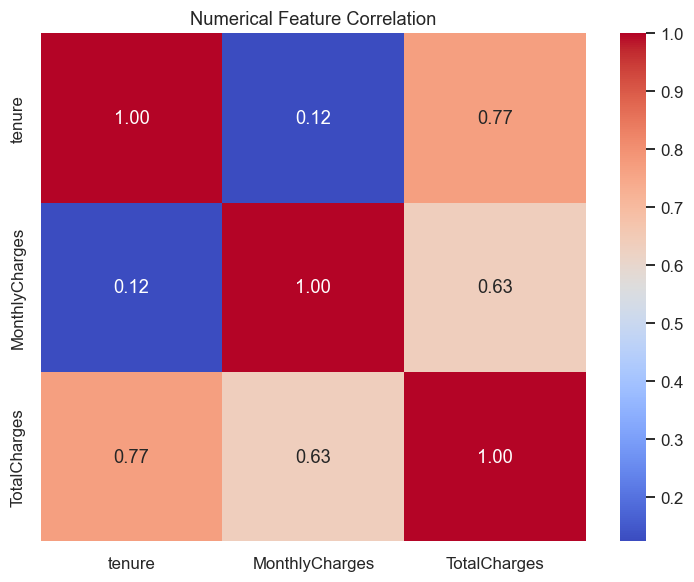

In [39]:
corr_matrix = train[pure_numerical_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Numerical Feature Correlation")

plt.show()

## 3.11 Outlier Analysis

- IQR yöntemi
- Her kolon için outlier sayısı

In [40]:
outlier_summary = []

for col in pure_numerical_cols:
    
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train[
        (train[col] < lower_bound) |
        (train[col] > upper_bound)
    ]
    
    outlier_summary.append({
        "feature": col,
        "outlier_count": len(outliers),
        "outlier_percentage": len(outliers) / len(train) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,feature,outlier_count,outlier_percentage
0,tenure,0,0.0
1,MonthlyCharges,0,0.0
2,TotalCharges,0,0.0


# 4. Key Findings & Notes

Bu bölümde yapılan Exploratory Data Analysis (EDA) sonucunda elde edilen önemli bulgular özetlenmiştir.

---

# Target Distribution

Churn dağılımı:

- No: 460,377
- Yes: 133,817

Oranlar:

- Churn = Yes → **%22.5**
- Churn = No → **%77.5**

Dataset **moderate class imbalance** içermektedir.

Bu nedenle model değerlendirmesinde **ROC-AUC metriği** kullanılması uygundur.

---

# Numerical Feature Observations

Dataset içinde 3 adet temel numerical feature bulunmaktadır:

- tenure
- MonthlyCharges
- TotalCharges

---

## Tenure

Tenure dağılımı **0–72 ay aralığındadır**.

Boxplot ve violin plot incelendiğinde:

- churn eden müşterilerin tenure değerleri genellikle **düşük**
- churn etmeyen müşteriler daha **uzun süreli müşteri**

Bu durum tenure'ın **churn için güçlü bir predictor** olduğunu göstermektedir.

Özet:

- düşük tenure → churn ihtimali yüksek
- yüksek tenure → churn ihtimali düşük

---

## MonthlyCharges

MonthlyCharges dağılımı yaklaşık:

20 – 120 aralığındadır.

Grafiklerde:

- churn eden müşterilerde **daha yüksek aylık ücretler**
- churn etmeyenlerde daha **düşük ortalama ücret**

Bu durum şu hipotezi destekler:

> yüksek fiyatlı planlar churn riskini artırabilir.

---

## TotalCharges

TotalCharges dağılımı **sağa çarpık (right-skewed)** yapıdadır.

Gözlemler:

- churn etmeyen müşterilerde **daha yüksek toplam ödeme**
- churn edenlerde **daha düşük toplam ödeme**

Bu durum tenure ile ilişkili görünmektedir.

Correlation analizi bunu doğrulamaktadır.

---

# Numerical Feature Correlation

Pearson korelasyon matrisi:

| Feature | Correlation |
|-------|-------|
tenure vs TotalCharges | **0.77**
MonthlyCharges vs TotalCharges | **0.63**
tenure vs MonthlyCharges | **0.12**

Önemli çıkarımlar:

- **TotalCharges büyük ölçüde tenure tarafından belirleniyor**
- tenure arttıkça TotalCharges doğal olarak artıyor

Bu nedenle potansiyel feature: AverageMonthlyCharge = TotalCharges / tenure


---

# Categorical Feature Observations

Dataset içerisinde **15 adet categorical feature** bulunmaktadır.

Öne çıkan bazı bulgular:

---

## Gender

Gender dağılımı oldukça dengelidir.

Churn oranı:

- Female ≈ Male

Bu nedenle gender güçlü bir churn predictor olmayabilir.

---

## Partner

Partner değişkeni churn üzerinde etkili görünmektedir.

Gözlem:

- Partner = No → churn oranı daha yüksek
- Partner = Yes → churn oranı daha düşük

Bu durum aile yapısının müşteri sadakatini artırabileceğini gösterebilir.

---

## Dependents

Dependents değişkeni churn ile ilişkilidir.

- Dependents = No → churn daha yüksek
- Dependents = Yes → churn daha düşük

---

## PhoneService

PhoneService değişkeni çok dengesizdir.

Çoğu müşteri PhoneService kullanmaktadır.

Bu nedenle model için bilgi değeri sınırlı olabilir.

---

## InternetService

InternetService churn ile güçlü ilişki göstermektedir.

Gözlem:

- Fiber optic → **yüksek churn oranı**
- DSL → orta churn
- No internet → çok düşük churn

Bu durum fiber kullanıcılarının daha yüksek fiyatlı planlarda olmasıyla ilişkili olabilir.

---

## Online Services

Aşağıdaki servislerde ortak bir pattern görülmektedir:

- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport

Gözlem:

- servis yok → churn yüksek
- servis var → churn daha düşük

Bu servisler müşteri bağlılığını artırıyor olabilir.

---

## Streaming Services

StreamingTV ve StreamingMovies için:

- streaming kullanan müşterilerde churn biraz daha yüksek.

Bu durum yüksek fiyatlı paketlerle ilişkili olabilir.

---

## Contract

Contract değişkeni churn için **en güçlü predictor'lardan biri** gibi görünmektedir.

Dağılım:

- Month-to-month → yüksek churn
- One year → orta
- Two year → çok düşük churn

Bu sonuç churn problemleri için klasik bir pattern'dir.

---

## PaperlessBilling

PaperlessBilling = Yes olan müşterilerde churn daha yüksek görünmektedir.

Bu durum dijital ödeme yöntemleri ile ilişkili olabilir.

---

## PaymentMethod

PaymentMethod değişkeni churn ile güçlü ilişki göstermektedir.

Özellikle:

Electronic check → **çok yüksek churn oranı**

Diğer ödeme yöntemlerinde churn daha düşüktür.

---

# Outlier Analysis

IQR yöntemi ile yapılan analizde:

- tenure
- MonthlyCharges
- TotalCharges

feature'larında **outlier bulunmamıştır**.

Bu nedenle outlier removal gerekli görünmemektedir.

---

# Data Quality

EDA sonuçlarına göre veri kalitesi oldukça iyidir.

- Missing value yok
- Duplicate row yok
- Outlier yok
- Feature distribution mantıklı

---

# Feature Engineering Opportunities

EDA sonucunda aşağıdaki feature engineering fikirleri ortaya çıkmaktadır.

### Average Monthly Charge
TotalCharges / tenure


---

### Service Count

Toplam servis sayısı:

---

### HasInternet
InternetService != "No"

---

### HasStreaming
StreamingTV OR StreamingMovies

---

### Contract Encoding

Contract süresi churn için güçlü sinyal içerir.

---

# Modeling Strategy

EDA bulgularına göre önerilen modelleme yaklaşımı:

1. Tree-based models

- LightGBM
- CatBoost
- XGBoost

2. Feature engineering

3. Model ensemble

---

# Final EDA Conclusion

Dataset:

- temiz
- eksik veri yok
- duplicate yok
- categorical ağırlıklı
- churn oranı %22.5

Bu veri seti için en uygun yaklaşım:

**Tree-based models + feature engineering**